In [3]:
##Graphviz를 이용해 데이터세트에 결정트리를 적용시 어떻게 서브 트리가 구성되고 만들어지는지 시각화.
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

#DecisionTree Classifier 생성 
dt_clf= DecisionTreeClassifier(random_state=156)

#붓꽃 데이터를 로딩하고, 학습과 테스트 데이터 세트로 분리
iris_data=load_iris()
X_train, X_test, y_train, y_test= train_test_split(iris_data.data, iris_data.target, test_size=0.2, random_state=11)

#DecisionTreeClassifier 학습 
dt_clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",156
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [4]:
from sklearn.tree import export_graphviz

#export_graphviz()의 호출 결과로 out_file로 저장된 tree.dot 파일 생성. 
export_graphviz(dt_clf, out_file="tree.dot", class_names=iris_data.target_names, \
    feature_names=iris_data.feature_names, impurity=True, filled=True)

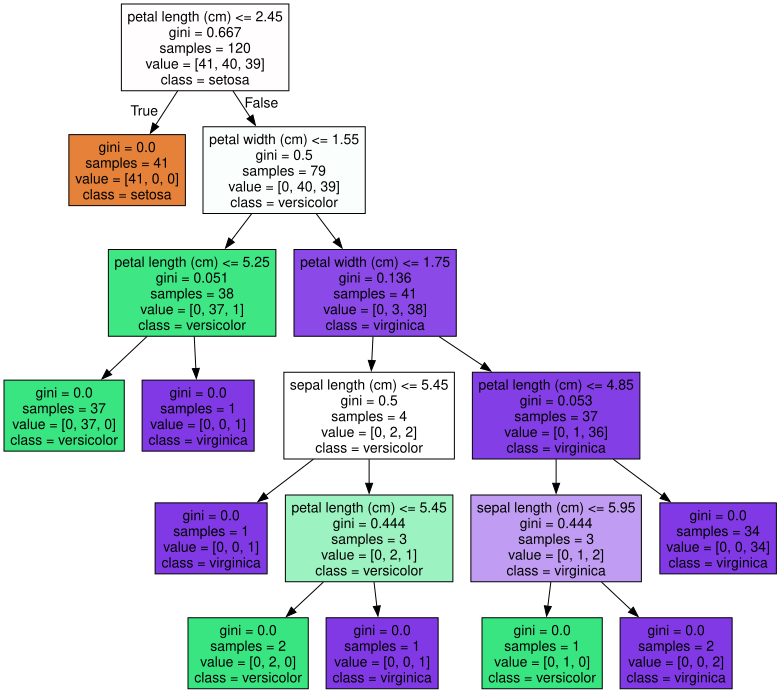

In [5]:
#tree.dot 이라는 파일 생성됨. 
import graphviz
#위에서 생성된 파일을 Graphviz가 읽어서 주피터 노트북상에서 시각화 
with open("tree.dot") as f:
    dot_graph=f.read()

graphviz.Source(dot_graph)

feature importances:
[0.025 0.    0.555 0.42 ]
sepal length (cm) : 0.025
sepal width (cm) : 0.000
petal length (cm) : 0.555
petal width (cm) : 0.420


<Axes: >

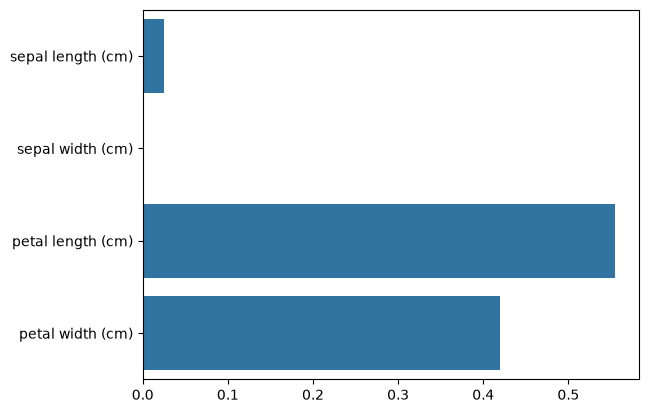

In [6]:
import seaborn as sns
import numpy as np
%matplotlib inline

#feature importance 추출
print("feature importances:\n{0}".format(np.round(dt_clf.feature_importances_,3))) 

#feature 별 importance 매핑 
for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_):
  print('{0} : {1:.3f}'.format(name, value))

#feature importance를 column 별로 시각화. 
sns.barplot(x=dt_clf.feature_importances_, y=iris_data.feature_names)

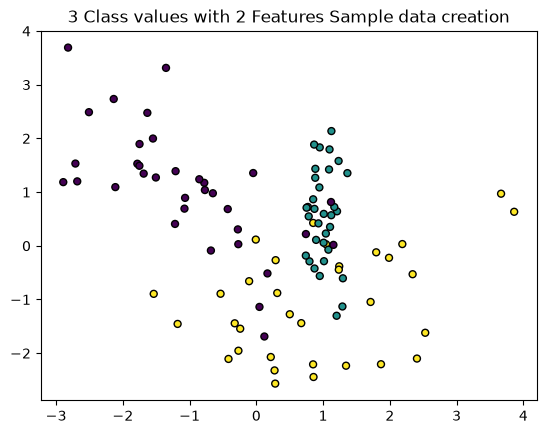

In [7]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
%matplotlib inline

plt.title("3 Class values with 2 Features Sample data creation")

#2차원 시각화를 위해서 피처는 2개, 클래스는 3가지 유형의 분류 샘플 데이터 생성.
x_features, y_labels = make_classification(n_features=2, n_redundant=0, n_informative=2,
                                           n_classes=3, n_clusters_per_class=1, random_state=0)

plt.scatter(x_features[:, 0], x_features[:, 1], marker='o', c=y_labels, s=25, edgecolor='k')

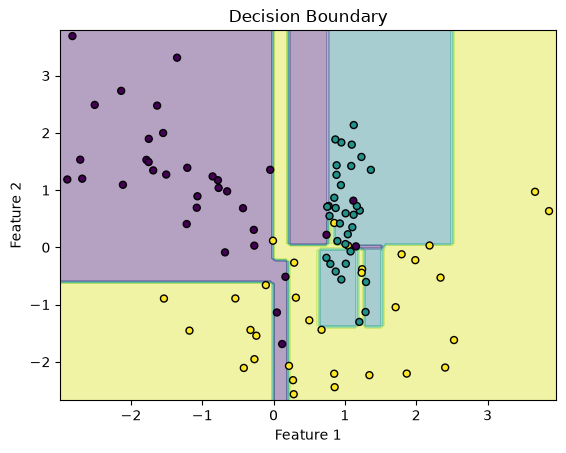

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function to visualize decision boundaries
def visualize_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                           np.linspace(y_min, y_max, 100))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=25, edgecolor='k')
    plt.title('Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=156).fit(x_features, y_labels)
visualize_boundary(dt_clf, x_features, y_labels)

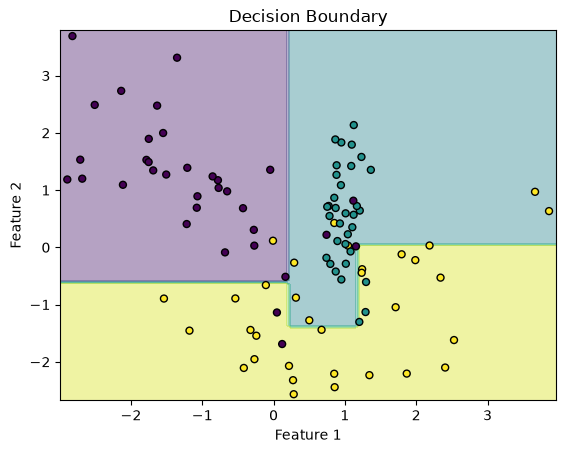

In [9]:
dt_clf = DecisionTreeClassifier(min_samples_leaf=6, random_state=156).fit(x_features, y_labels)
visualize_boundary(dt_clf, x_features, y_labels)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

#feature.txt 파일에는 피처 이름 index와 피처명이 공백으로 분리되어 이ㅛ음. 이를 Dataframe으로 로드.
feature_name_df = pd.read_csv('./human_activity/features.txt', sep='\s+',
                               header=None, names=['column_index', 'column_name'])
# names=['column_index', 'column_name'] : 직접 컬럼명 지정. 

#피처명 인덱스를 제거하고, 피처명만 리스트 객체로 생성한 뒤 샘플로 10개만 추출 
feature_name = feature_name_df.iloc[:, 1].values.tolist() #피처명들을 리스트로 만ㄷ르기. 
print('전체 피처명에서 10개만 추출:', feature_name[:10])

전체 피처명에서 10개만 추출: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


In [11]:
#중복된 피처명은 허용x -> 피처명에 _1, _2 등 추가해야함 
#중복된 피처명이 얼마나 있는지 알아보기 
feature_dup_df=feature_name_df.groupby('column_name').count() #컬럼이름 | 남은 컬럼인 index에 대해 count
print(feature_dup_df[feature_dup_df['column_index']>1].count())
feature_dup_df[feature_dup_df['column_index']>1 ].head() 

#42개의 피처명이 중복돼있음을 확인가능 

column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


In [12]:
#중복된 피처명에 _1, _2  추가로 부여-> 새로운 피처명을 가지는 데프를 반환하는 함수 생성 
def get_new_feature_name_df(old_feature_name_df):
  feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                                                                       columns=['dup_cnt'])

  feature_dup_df = feature_dup_df.reset_index() #인덱스를 0부터 다시 매김. 
  new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
  new_feature_name_df['column_name'] = new_feature_name_df[['column_name',
                                                          'dup_cnt']].apply(lambda x : x.iloc[0]+'_'+str(x.iloc[1])
                                                            if x.iloc[1] > 0 else x.iloc[0], axis=1)

  new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
  return new_feature_name_df

In [13]:
#train 디렉터리의 학습용, test 디렉터리의 테스트용ㅇㅡㄹ 데이터프레임으로 로드 
#레이블의 칼럼: 'action' 
import pandas as pd

def get_human_dataset():
  #각 데이터파일은 공백으로 분리 -> sep='\s+' (=공백이 한개 이상 의미.)
  feature_name_df = pd.read_csv('./human_activity/features.txt', sep='\s+',
                                header=None, names=['column_index', 'column_name'])
  
  #중복된 피처명을 수정, 피처인덱스 drop하는 get_new_feature_name_df() 사용. - 신규피처명 데이터프레임 생성. 
  new_feature_name_df = get_new_feature_name_df(feature_name_df)

 # 학습 피처 데이터세트, 테스트 피처데이터를 Dataframe으로 로딩. 칼럼며은 feature_name 
  feature_name = new_feature_name_df.iloc[:, 1].values.tolist() #칼럼명을 리스트로 변경
  X_train = pd.read_csv('./human_activity/train/X_train.txt', sep='\s+', names=feature_name)
  X_test = pd.read_csv('./human_activity/test/X_test.txt', sep='\s+', names=feature_name)

# 학습 레이블 데이터세트, 테스트 레이블 데이터를 Dataframe으로 로딩. 칼럼며은 action 
  y_train = pd.read_csv('./human_activity/train/y_train.txt', header=None, names=['action'])
  y_test = pd.read_csv('./human_activity/test/y_test.txt', header=None, names=['action'])

  return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = get_human_dataset()

In [14]:
print('## 학습 피처 데이터셋 info()')
print(X_train.info())
#7352개 데이터, 561개 피처 
#피처가 모두 float 숫자형이므로 인코딩 필요x 

## 학습 피처 데이터셋 info()
<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 31.5 MB
None


In [15]:
print(y_train['action'].value_counts())

action
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


In [16]:
#동작 예측 분류 수행 
#결정트리 디폴트 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier(random_state=156)
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

print('DecisionTreeClassifier 기본 하이퍼 파라미터:\n', dt_clf.get_params())

결정 트리 예측 정확도: 0.8548
DecisionTreeClassifier 기본 하이퍼 파라미터:
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 156, 'splitter': 'best'}


In [18]:
from sklearn.model_selection import GridSearchCV

#결정 트리 깊이 설정 
#사이킷런의 결정 트리의 깊이를 조절할 수 있는 하이퍼 파라미터: max_depth 변화기키면서 예측성능 확인. 

params = {
    'max_depth' : [6, 8, 10, 12, 16, 20, 24],
    'min_samples_split' : [16]

}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(X_train, y_train)
print('GridSearchCV 최고 평균 정확도 수치: {0:.4f}'.format(grid_cv.best_score_))
print('GirdSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

#max_depth': 8일떄 최고 평균 정확도가 나온다. 

Fitting 5 folds for each of 7 candidates, totalling 35 fits


KeyboardInterrupt: 

In [ ]:
#max_depth증가함에 따라 예측성능이 "어떻게" 변하는지 확인 
#cv_results_속성 확인

#GridSearchCV 객체의 cv_results_속성을 df로 생성 
cv_reaults_df= pd.DataFrame(grid_cv.cv_results_)

#max_depth 파라미터 값과 그때의 테ㅡ스트 세트, 학습 데이터 세트의 정확도 수치 추출 
cv_reaults_df[['param_max_depth', 'mean_test_score']]

,param_max_depth,mean_test_score
0,6,0.847662
1,8,0.854879
2,10,0.852705
3,12,0.845768
4,16,0.847127
5,20,0.848624
6,24,0.848624


In [ ]:
#max_depth 변경하며 확인 
max_depths = [6, 8, 10, 12, 16, 20, 24]

for depth in max_depths:
  dt_clf = DecisionTreeClassifier(max_depth=depth, min_samples_split=16, random_state=156)
  dt_clf.fit(x_train, y_train)
  pred = dt_clf.predict(x_test)
  accuracy = accuracy_score(y_test, pred)
  print('max_depth = {0} 정확도: {1:.4f}'.format(depth, accuracy))

max_depth = 6 정확도: 0.8551
max_depth = 8 정확도: 0.8717
max_depth = 10 정확도: 0.8599
max_depth = 12 정확도: 0.8571
max_depth = 16 정확도: 0.8599
max_depth = 20 정확도: 0.8565
max_depth = 24 정확도: 0.8565


In [ ]:
#max_depth, min_samples_split 같이 변경하며 확인 
params = {
    'max_depth' : [8, 12, 16, 20],
    'min_samples_split' : [16, 24 ],
}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(x_train, y_train)
print('GridSearchCV 최고 평균 정확도 수치: {0:.4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
GridSearchCV 최고 평균 정확도 수치: 0.8549
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


In [ ]:
#최고의 하이퍼 파라미터 조합으로 학습이 완료된 Estimator을 가지고 예측 수행. 
best_df_clf = grid_cv.best_estimator_
pred1 = best_df_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred1)
print('결정 트리 예측 정확도:{0:.4f}.'.format(accuracy))

결정 트리 예측 정확도:0.8717.


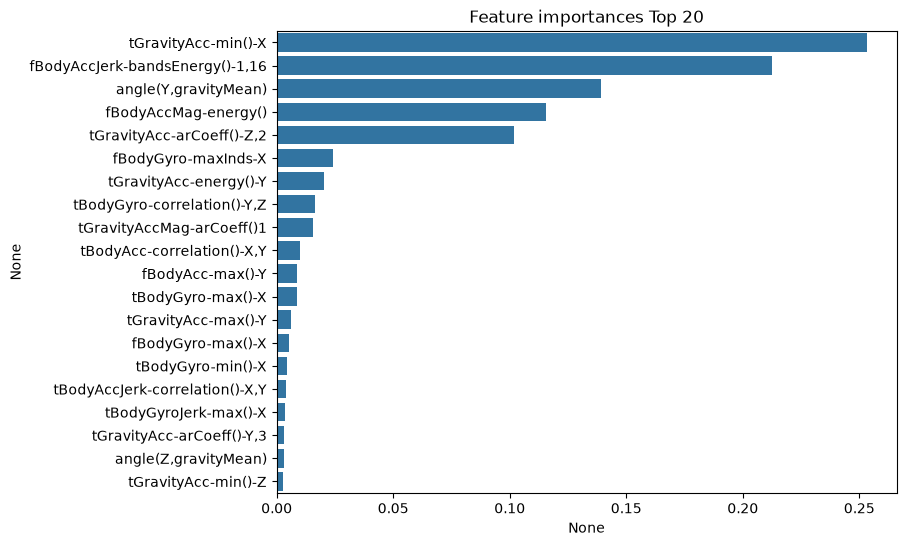

In [ ]:
#결정 트리에서 각 피처의 중요도를 feature_importances_속성으로 알아보기 

import seaborn as sns

ftr_importances_values = best_df_clf.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=x_train.columns)
ftr_top20=ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y = ftr_top20.index)
plt.show()

In [ ]:
import pandas as pd

#로지스틱 회귀와 KNN을 기반으로 하여, 소프트 보팅 방식으로 새로운 보팅분류기 만들기 
from sklearn.ensemble import VotingClassifier #보팅 분류기 생성 
from sklearn.linear_model import LogisticRegression #로지스틱회귀
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer=load_breast_cancer()

data_df= pd.DataFrame(cancer.data, columns=cancer.feature_names)
data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [ ]:
#개별 모델은 로지스틱회귀, KNN
lr_clf= LogisticRegression(solver='liblinear')
knn_clf= KNeighborsClassifier(n_neighbors=8)

#개별 모델을 소프트 보팅 기반의 앙상블 모델로 구현한 분류기
vo_clf= VotingClassifier(estimators=[("LR", lr_clf), ('KNN', knn_clf)], voting='soft')

X_train, X_test, y_train, y_test= train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=156)

#VotingClassifier 학습/예측/평가 
vo_clf.fit(X_train, y_train)
pred=vo_clf.predict(X_test)
print('Voting 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

#개별 모델의 학습/예측/평가 
classifiers= [lr_clf, knn_clf]
for classifier in classifiers:
    classifier.fit(X_train, y_train)
    pred=classifier.predict(X_test)
    class_name = classifier.__class__.__name__
    print('{0} 정확도: {1:.4f}'.format(class_name, accuracy_score(y_test, pred)))

Voting 분류기 정확도: 0.9561
LogisticRegression 정확도: 0.9474
KNeighborsClassifier 정확도: 0.9386


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

#결정트리에서 사용한 get_human_dataset()을 이용해 학습/테스트용 데이터프레임 반환 
X_train, X_test, y_train, y_test= get_human_dataset()

#랜덤 포레스트 학습/별도의데이터세트로 예측성능평가 
rf_clf= RandomForestClassifier(random_state=0, max_depth=8)
rf_clf.fit(X_train, y_train)
pred=rf_clf.predict(X_test)
accuracy= accuracy_score(y_test, pred)
print('랜덤 포레스트 정확도:{0:.4f}'.format(accuracy))


랜덤 포레스트 정확도:0.9196


In [ ]:
#랜덤 포레스트의 하이퍼 파라미터 튜닝 
from sklearn.model_selection import GridSearchCV

params={
    'max_depth':[8, 16, 24],
    'min_samples_leaf':[1, 6, 12],
    'min_samples_split':[2, 8, 16]
}

#RandomForestClassifier 객체 생성 후 GridSearchCV 수행 
rf_clf= RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
grid_cv= GridSearchCV(rf_clf, param_grid=params, cv=2, n_jobs=-1)
grid_cv.fit(X_train, y_train)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)
print('최고 예측 정확도:{0:.4f}'.format(grid_cv.best_score_))


최적 하이퍼 파라미터:
 {'max_depth': 16, 'min_samples_leaf': 6, 'min_samples_split': 2}
최고 예측 정확도:0.9165


In [ ]:
#별도의 테스트 데이터 세트에서 예측 성능 측정 
estimator= grid_cv.best_estimator_ 
#estimator= 최적의 estimator 설정. 
#(GridSearchCV가 찾은 가장 좋은 하이퍼파라미터 조합으로 학습된 랜덤 포레스트 분류 모델)
pred= estimator.predict(X_test) 
print('예측 정확도:{0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도:0.9260


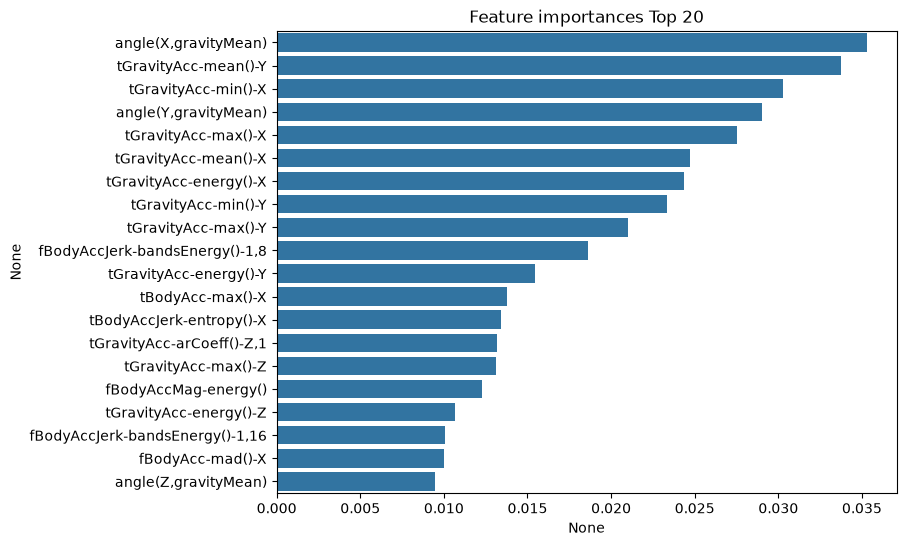

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

ftr_importances_values = estimator.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8, 6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()

